# U.S. Medical Insurance Costs

In this project, a **CSV** file with medical insurance costs will be investigated using Python fundamentals. The goal with this project will be to analyze various attributes within **insurance.csv** to learn more about the patient information in the file and gain insight into potential use cases for the dataset.

In [2]:
#import csv library
import csv

In [255]:
#import libraries to make plots
import matplotlib.pyplot as plt
import matplotlib.cbook as cbook
import numpy as np

In [263]:
#defining function to add annotation to boxplots
def annotate_all(data, ax):
    stats = cbook.boxplot_stats(data)
    for i in range(len(stats)):
        q1 = stats[i]['q1']
        median = stats[i]['med']
        q3 = stats[i]['q3']
        whislo = stats[i]['whislo']
        whishi = stats[i]['whishi']
        ax.text(i+1, q1, f'{q1:.1f}', ha='center', va='bottom', fontsize=10)
        ax.text(i+1, median, f'{median:.1f}', ha='center', va='bottom')
        ax.text(i+1, q3, f'{q3:.1f}', ha='center', va='top', fontsize=10)
        ax.text(i+1, whislo, f'{whislo:.1f}', ha='center', va='top', fontsize=10)
        ax.text(i+1, whishi, f'{whishi:.1f}', ha='center', va='bottom', fontsize=10)

In [9]:
#import dataset
insurance_data = []
with open("datasets/insurance.csv", newline='') as data_file:
    data_reader = csv.DictReader(data_file)
    for entry in data_reader:
        insurance_data.append(entry)

The dataset has seven columns: `age`, `sex`, `bmi`, `children`, `smoker`, `region`, and `charges`.

In [30]:
ages = [int(record["age"]) for record in insurance_data]
sexes = [record["sex"] for record in insurance_data]
bmis = [float(record["bmi"]) for record in insurance_data]
children = [int(record["children"]) for record in insurance_data]
smokers = [record["smoker"] for record in insurance_data]
regions = [record["region"] for record in insurance_data]
charges = [float(record["charges"]) for record in insurance_data]

## Summary Statistics

### Number of Women vs Men

In [97]:
num_total = len(insurance_data)
num_women = sexes.count("female")
num_men = sexes.count("male")
print("The dataset contains {total} entries: {women} women and {men} men.".format(total=num_total, 
                                                                                  women=num_women, 
                                                                                  men=num_men))

The dataset contains 1338 entries: 662 women and 676 men.


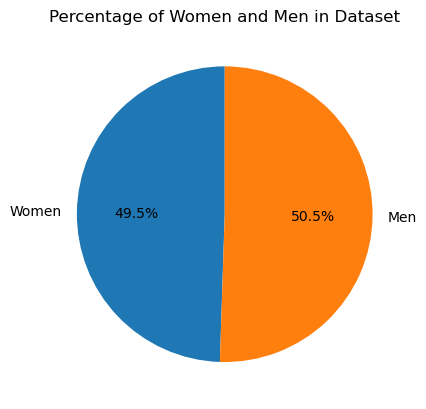

In [96]:
plt.pie([num_women, num_men], labels=["Women", "Men"], startangle=90, autopct='%1.1f%%')
plt.title('Percentage of Women and Men in Dataset')
plt.show()

### Ages

In [76]:
print("Mean Age: {avg}\nMinimum Age: {min}\nMaximum Age: {max}".format(avg=round(np.mean(ages),1), min=min(ages), max=max(ages)))

Mean Age: 39.2
Minimum Age: 18
Maximum Age: 64


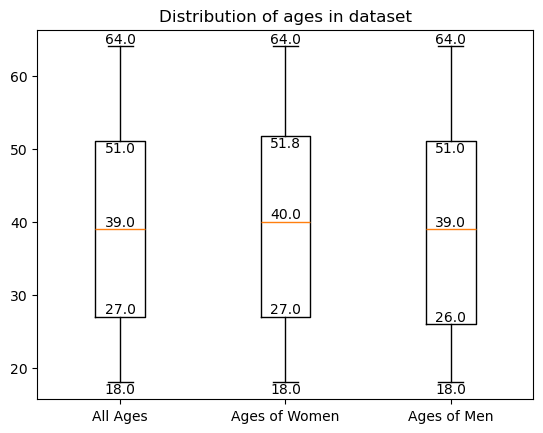

In [305]:
ages_female = [int(record["age"]) for record in insurance_data if record["sex"] == "female"]
ages_male = [int(record["age"]) for record in insurance_data if record["sex"] == "male"]
fig, ax = plt.subplots()
ax.boxplot([ages, ages_female, ages_male], tick_labels=['All Ages', 'Ages of Women', 'Ages of Men'])
annotate_all([ages, ages_female, ages_male], ax)
plt.title("Distribution of ages in dataset")
plt.show()

### BMI

In [281]:
print("Mean BMI: {avg}\nMinimum BMI: {min}\nMaximum BMI: {max}".format(avg=round(np.mean(bmis),1), 
                                                                       min=min(bmis), 
                                                                       max=max(bmis)))

Mean BMI: 30.7
Minimum BMI: 15.96
Maximum BMI: 53.13


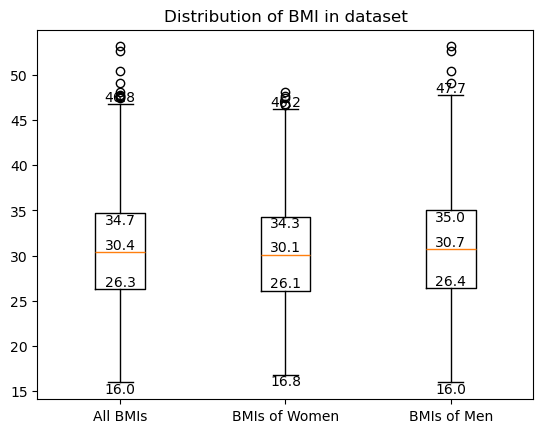

In [283]:
bmis_female = [float(record["bmi"]) for record in insurance_data if record["sex"] == "female"]
bmis_male = [float(record["bmi"]) for record in insurance_data if record["sex"] == "male"]
data = [bmis, bmis_female, bmis_male]
labels = ['All BMIs', 'BMIs of Women', 'BMIs of Men']
fig, ax = plt.subplots()
ax.boxplot(data, tick_labels=labels)
annotate_all(data, ax)
plt.title("Distribution of BMI in dataset")
plt.show()

### Number of Children

In [277]:
print("Mean # of Children: {avg}\nMinimum # of Children: {min}\nMaximum # of Children: {max}".format(avg=round(np.mean(children),1), 
                                                                                                     min=min(children), 
                                                                                                     max=max(children)))

Mean # of Children: 1.1
Minimum # of Children: 0
Maximum # of Children: 5


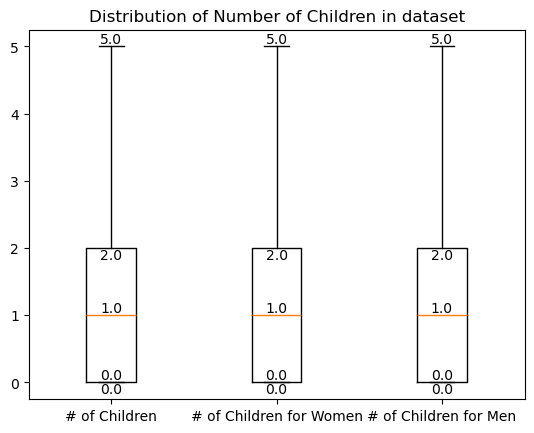

In [280]:
children_female = [int(record["children"]) for record in insurance_data if record["sex"] == "female"]
children_male = [int(record["children"]) for record in insurance_data if record["sex"] == "male"]
data = [children, children_female, children_male]
labels = ['# of Children', '# of Children for Women', '# of Children for Men']
fig, ax = plt.subplots()
ax.boxplot(data, tick_labels=labels)
annotate_all(data, ax)
plt.title("Distribution of Number of Children in dataset")
plt.show()

### Smokers

In [290]:
num_smokers = smokers.count("yes")
num_nonsmokers = smokers.count("no")
print("The dataset contains {smoker} smokers and {nonsmoker} non-smokers.".format(smoker=num_smokers,
                                                                                  nonsmoker=num_nonsmokers))

The dataset contains 274 smokers and 1064 non-smokers.


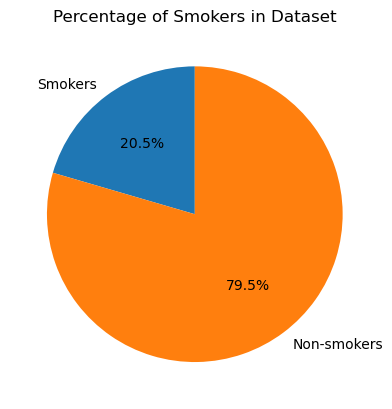

In [291]:
plt.pie([num_smokers, num_nonsmokers], labels=["Smokers", "Non-smokers"], startangle=90, autopct='%1.1f%%')
plt.title('Percentage of Smokers in Dataset')
plt.show()

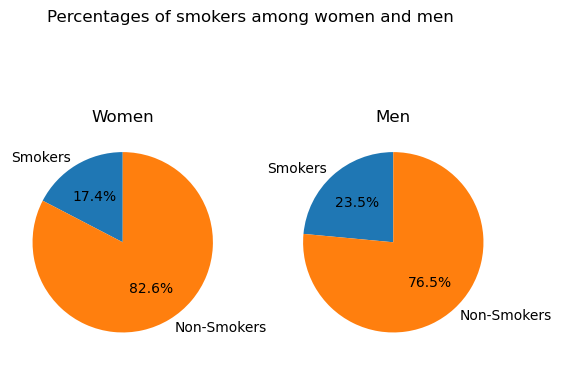

In [303]:
smoker_women = 0
nonsmoker_women = 0
smoker_men = 0
nonsmoker_men = 0
for record in insurance_data:
    if record["smoker"] == "yes":
        if record["sex"] == "female":
            smoker_women += 1
        else:
            smoker_men += 1
    else:
        if record["sex"] == "female":
            nonsmoker_women += 1
        else:
            nonsmoker_men += 1
fig, (ax1, ax2) = plt.subplots(1,2)
ax1.pie([smoker_women, nonsmoker_women], labels=["Smokers", "Non-Smokers"], autopct='%1.1f%%', startangle = 90)
ax1.set_title("Women")
ax2.pie([smoker_men, nonsmoker_men], labels=["Smokers", "Non-Smokers"], autopct='%1.1f%%', startangle = 90)
ax2.set_title("Men")
plt.suptitle("Percentages of smokers among women and men")
plt.show()

### Regions

In [308]:
list_of_regions = []
for region in regions:
    if region not in list_of_regions: list_of_regions.append(region)
list_of_regions

['southwest', 'southeast', 'northwest', 'northeast']

In [309]:
num_southwest = regions.count('southwest')
num_southeast = regions.count('southeast')
num_northwest = regions.count('northwest')
num_northeast = regions.count('northeast')
print("Number of Records By Region:\nSouthwest: {sw}\nSoutheast: {se}\nNorthwest: {nw}\nNortheast: {ne}".format(sw=num_southwest,
                                                                                                              se=num_southeast,
                                                                                                              nw=num_northwest,
                                                                                                              ne=num_northeast))

Number of Records By Region:
Southwest: 325
Southeast: 364
Northwest: 325
Northeast: 324
